# house price prediction 

## Task 1:Data loading and exploration

In [53]:
import pandas as pd
import numpy as np
df=pd.read_csv("Housing.csv")


In [54]:
print("first 10 rows:",df.head(10))
print("no. of rows and columns:",df.shape)
print("\n columns",df.columns.tolist())

first 10 rows:       price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes

In [55]:
target="price"
features=[col for col in df.columns if col!=target]
print("\nTarget Column:",target)
print("\nFeature columns:",features)




Target Column: price

Feature columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [56]:
print("missing columns:")
print(df.isnull().sum())

missing columns:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


## Task 2:Data Cleaning

In [57]:
print("duplicate rows:",df.duplicated().sum())
df.drop_duplicates(inplace=True)


duplicate rows: 0


In [58]:


for col in df.columns:
    if df[col].dtype=='object':
        # Check if mode exists before accessing it
        mode_values = df[col].mode()
        if len(mode_values) > 0:
            df[col] = df[col].fillna(mode_values[0])
        else:
            # If no mode exists (all NaN), fill with a default value or skip
            df[col] = df[col].fillna('Unknown')  # or you could use df[col].fillna(method='ffill')
    else:
        # Check if column has any non-null values before calculating median
        if df[col].notna().any():
            df[col] = df[col].fillna(df[col].median())
        else:
            # If all values are NaN, fill with 0 or skip
            df[col] = df[col].fillna(0)  # or you could leave it as NaN

print("\nMissing values after cleaning:")
print(df.isnull().sum())       
        


Missing values after cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [59]:
df=pd.get_dummies(df,drop_first=True)

In [60]:
print("\nDataset after encoding:")
display(df.head())



Dataset after encoding:


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [61]:
print("Final Dataset shape:",df.shape)

Final Dataset shape: (545, 14)


# Task 3: Model Building

In [62]:
from sklearn.model_selection import train_test_split
x=df.drop("price",axis=1)
y=df["price"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
print("Training Data Shape:",x_train.shape)
print("Testing Data Shape:",x_test.shape)

Training Data Shape: (436, 13)
Testing Data Shape: (109, 13)


# Linear Regression Model

In [63]:
from sklearn.linear_model import LinearRegression
lr_model=LinearRegression()
lr_model.fit(x_train,y_train)
print("Linear Regression Model Trained Successfullt")

Linear Regression Model Trained Successfullt


In [64]:
y_pred_lr=lr_model.predict(x_test)
print(y_pred_lr[:5])

[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


In [65]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score  # Changed from r2_error to r2_score
import numpy as np

lr_mae=mean_absolute_error(y_test,y_pred_lr)
lr_rmse=np.sqrt(mean_squared_error(y_test,y_pred_lr))
lr_r2=r2_score(y_test,y_pred_lr)  # Using the correct function name
print("Linear Regression Results")
print("MAE:",lr_mae)
print("RMSE:",lr_rmse)  # Added missing opening parenthesis
print("R2 Score:",lr_r2)

Linear Regression Results
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


# Randon Forest Regresser

In [66]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)
print("Random Forest Model Trained Successfully")



Random Forest Model Trained Successfully


In [67]:
y_pred_rf=rf_model.predict(x_test)
print(y_pred_rf[:5])

[5377680.   7287070.   3747528.75 4502120.   3748885.  ]


In [68]:
rf_mae=mean_absolute_error(y_test,y_pred_rf)
rf_rmse=np.sqrt(mean_squared_error(y_test,y_pred_rf))
rf_r2=r2_score(y_test,y_pred_rf)
print("Random Forest Results")
print("MAE:",rf_mae)
print("RMSE:",rf_rmse)
print("R2:",rf_r2)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2: 0.611918531405699


# Compare MOdels

In [69]:
import pandas as pd
comparison=pd.DataFrame({"Model":["Linear Regression","Random Forest"],
                         "MAE":[lr_mae,rf_mae],
                         "RMSE":[lr_rmse,rf_rmse],
                         "R2 Score":[lr_r2,rf_r2]})
comparison


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Task 4: Visualization

Matplotlib is building the font cache; this may take a moment.


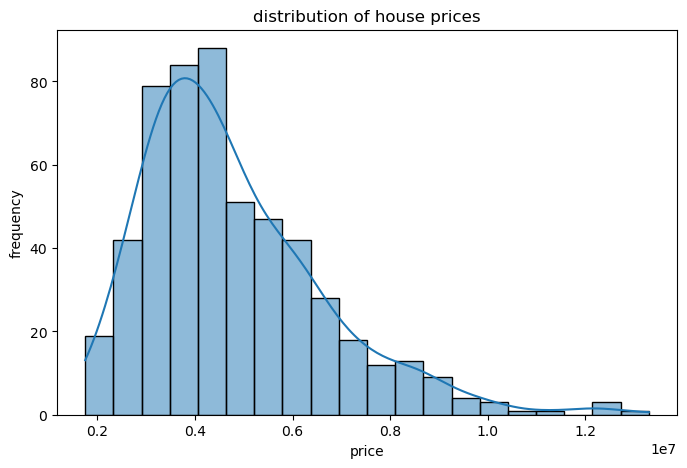

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df['price'],bins=20,kde=True)
plt.title("distribution of house prices")
plt.xlabel("price")
plt.ylabel("frequency")
plt.show()

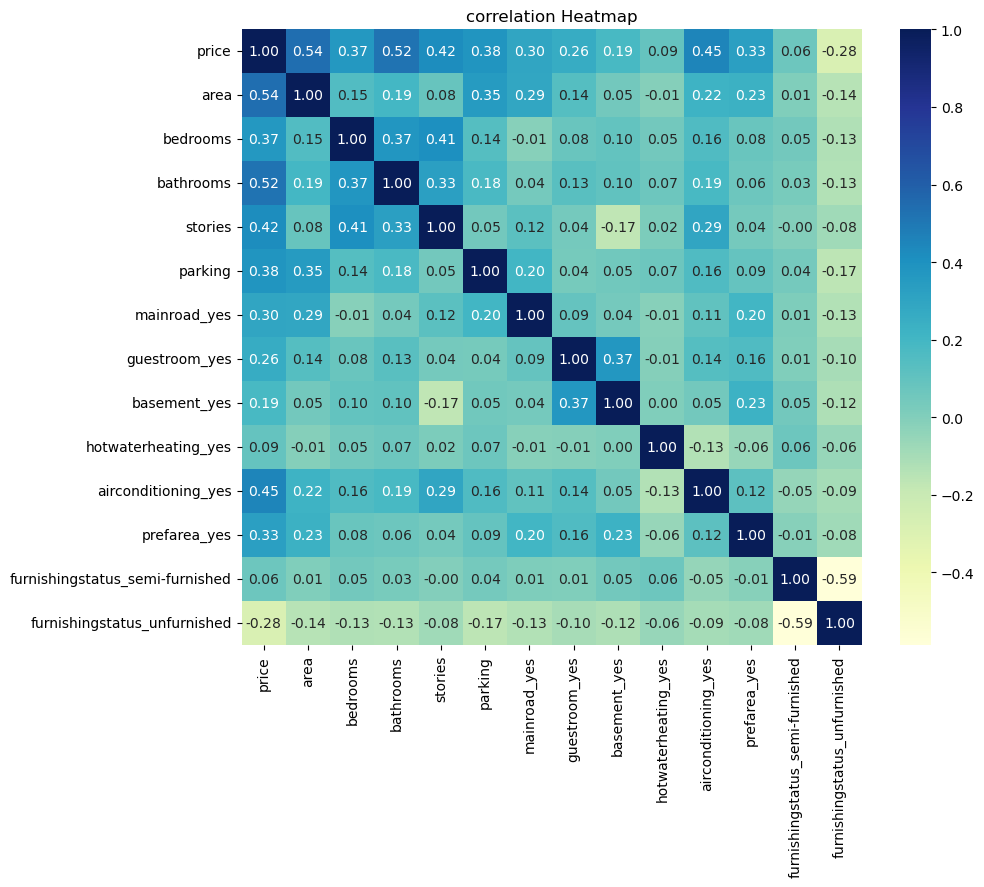

In [73]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='YlGnBu',fmt='.2f')
plt.title("correlation Heatmap")
plt.show()

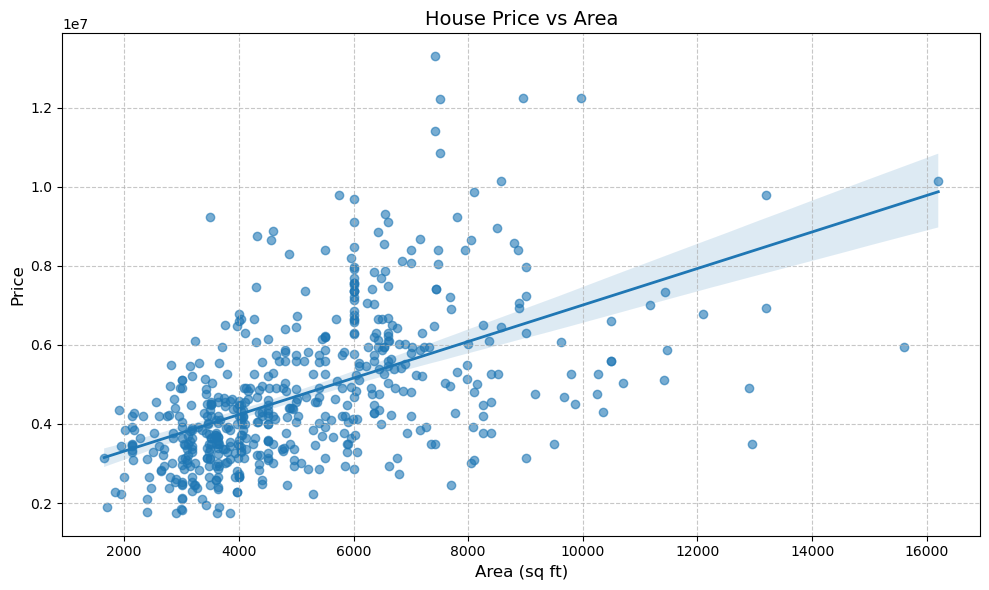

In [75]:
plt.figure(figsize=(10,6))
sns.regplot(x=df['area'],
            y=df['price'],
            scatter_kws={'alpha':0.6},
            line_kws={'linewidth':2})
plt.title("House Price vs Area",fontsize=14)
plt.xlabel("Area (sq ft)",fontsize=12)
plt.ylabel("Price",fontsize=12)
plt.grid(True,linestyle='--',alpha=0.7)
plt.tight_layout()
plt.show()

# Project Summary and Insights

## This project analyzed various factors affecting house prices and built prediction models using Linear Regression and Random Forest Regressor.The correlation analysis showed that Area,Air Conditioning,Bathroom and Stories had the strongest influence on house prices.Among the models,Random Forest Regressor performed better than Linear Regression.The model was able to predict house prices well based on available features.One more suprising finding was that some amenities such as guest room and parking lot had a weaker impact on price than expected. Based on these findings,a real estate business should focus on promoting properties with larger area and better facilities,as these features contribute most to higher property values.